In [ ]:
!pip install numpy pandas scikit-learn tensorflow keras nltk tqdm


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving rockyou.txt to rockyou.txt


In [ ]:
import pandas as pd

# Define file path
file_path = "/content/rockyou.txt"  # Ensure correct path

# Read file efficiently
with open(file_path, "r", encoding="latin-1") as f:
    passwords = [line.strip() for line in f if line.strip()]  # Remove empty lines

# Convert to DataFrame
df = pd.DataFrame(passwords, columns=["password"])

# Drop duplicates for cleaner data
df.drop_duplicates(inplace=True)

# Display dataset info
print(f"Dataset Size: {df.shape[0]} passwords")
df.head()


Dataset Size: 14343755 passwords


,password
0,123456
1,12345
2,123456789
3,password
4,iloveyou


In [ ]:
import re

def password_strength(password):
    if len(password) < 6:
        return 0  # Weak
    elif re.search(r'\d', password) and re.search(r'[A-Za-z]', password):
        return 1  # Medium
    elif re.search(r'[A-Za-z]', password) and re.search(r'\d', password) and re.search(r'[@$!%*?&#]', password):
        return 2  # Strong
    return 0  # Default Weak

df["strength"] = df["password"].apply(password_strength)

# Check distribution
df["strength"].value_counts()


,count
strength,
1,7311431
0,7032324


In [ ]:
import numpy as np

def extract_features(password):
    length = len(password)
    digits = len(re.findall(r'\d', password))
    uppercase = len(re.findall(r'[A-Z]', password))
    special_chars = len(re.findall(r'[@$!%*?&#]', password))

    return [length, digits, uppercase, special_chars]

df["features"] = df["password"].apply(extract_features)

# Prepare X (features) and y (labels)
X = np.array(df["features"].tolist())
y = np.array(df["strength"])


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Create the model
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')  # Output: Weak, Medium, Strong
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
358594/358594 ━━━━━━━━━━━━━━━━━━━━ 1031s 3ms/step - accuracy: 0.9877 - loss: 0.0479 - val_accuracy: 0.9975 - val_loss: 0.0168
Epoch 2/10
358594/358594 ━━━━━━━━━━━━━━━━━━━━ 1111s 3ms/step - accuracy: 0.9933 - loss: 0.0265 - val_accuracy: 0.9974 - val_loss: 0.0150
Epoch 3/10
358594/358594 ━━━━━━━━━━━━━━━━━━━━ 1071s 3ms/step - accuracy: 0.9892 - loss: 0.0339 - val_accuracy: 0.9974 - val_loss: 0.0157
Epoch 4/10
358594/358594 ━━━━━━━━━━━━━━━━━━━━ 1085s 3ms/step - accuracy: 0.9892 - loss: 0.0338 - val_accuracy: 0.9975 - val_loss: 0.0159
Epoch 5/10
358594/358594 ━━━━━━━━━━━━━━━━━━━━ 1058s 3ms/step - accuracy: 0.9893 - loss: 0.0336 - val_accuracy: 0.9784 - val_loss: 0.0418
Epoch 6/10
358594/358594 ━━━━━━━━━━━━━━━━━━━━ 1131s 3ms/step - accuracy: 0.9893 - loss: 0.0338 - val_accuracy: 0.9975 - val_loss: 0.0138
Epoch 7/10
358594/358594 ━━━━━━━━━━━━━━━━━━━━ 1070s 3ms/step - accuracy: 0.9893 - loss: 0.0336 - val_accuracy: 0.9975 - val_loss: 0.0126
Epoch 8/10
358594/358594 ━━━━━━━━━━━━━━━━

In [ ]:
test_password = "Secure@987"
test_features = np.array([extract_features(test_password)])

prediction = model.predict(test_features)
strength_label = ["Weak", "Medium", "Strong"][np.argmax(prediction)]
print(f"Password Strength: {strength_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Password Strength: Medium


In [ ]:
import tensorflow as tf

# Save the trained model
model.save("password_strength_model.h5")


pip install flask flask-cors gunicorn


In [ ]:
from google.colab import files
files.download("password_strength_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install matplotlib seaborn plotly


In [ ]:
import re

def password_strength(password):
    if len(password) < 6:
        return 0  # Weak
    elif len(password) < 8:
        return 1  # Moderate
    elif re.search(r'[A-Z]', password) and re.search(r'[\d]', password) and re.search(r'[\W]', password):
        return 3  # Very Strong
    else:
        return 2  # Strong

# Apply function to all passwords
df["password_strength"] = df["password"].apply(password_strength)

# Display counts
df["password_strength"].value_counts()


,count
password_strength,
2,9550363
1,4453879
0,279875
3,59638


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [ ]:
strength_counts = df["password_strength"].value_counts().sort_index()
labels = ["Weak", "Moderate", "Strong"]


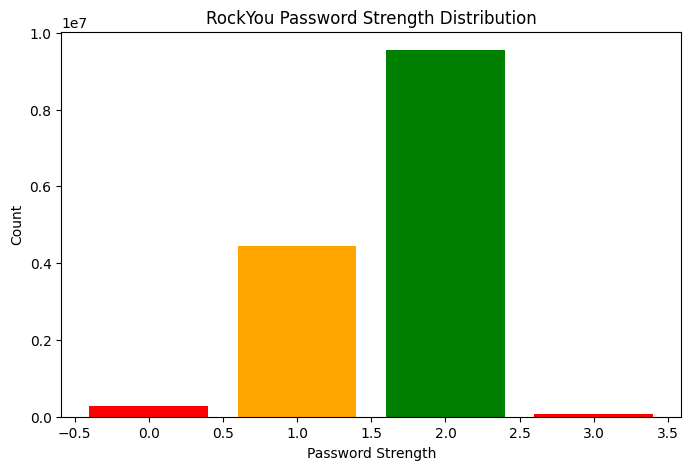

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(strength_counts.index, strength_counts.values, color=['red', 'orange', 'green'])

plt.xlabel('Password Strength')
plt.ylabel('Count')
plt.title('RockYou Password Strength Distribution')

plt.show()


<ipython-input-27-5de272a0860f>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strength_counts.index, y=strength_counts.values, palette="viridis")


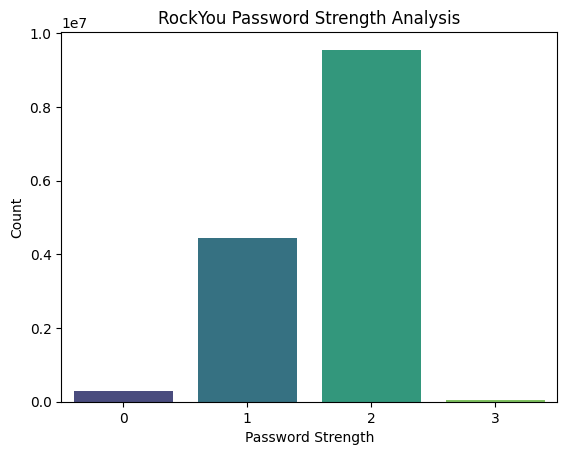

In [ ]:
sns.barplot(x=strength_counts.index, y=strength_counts.values, palette="viridis")

plt.xlabel('Password Strength')
plt.ylabel('Count')
plt.title('RockYou Password Strength Analysis')

plt.show()


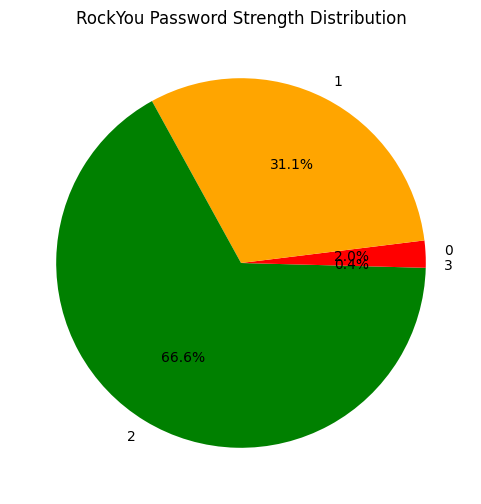

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(strength_counts, labels=strength_counts.index, autopct='%1.1f%%', colors=['red', 'orange', 'green'])
plt.title("RockYou Password Strength Distribution")
plt.show()


# DATA ANALYSIS

In [ ]:
print("Total passwords in dataset:", len(df))


Total passwords in dataset: 14343755


In [ ]:
print(df["password"].value_counts().head(10))


password
*7Â¡Vamos!    1
123456           1
12345            1
123456789        1
password         1
iloveyou         1
princess         1
1234567          1
rockyou          1
12345678         1
Name: count, dtype: int64


In [ ]:
df["password_length"] = df["password"].apply(len)
print("Average Password Length:", df["password_length"].mean())


Average Password Length: 8.754377915685259


# DATA VISUALIZATION

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


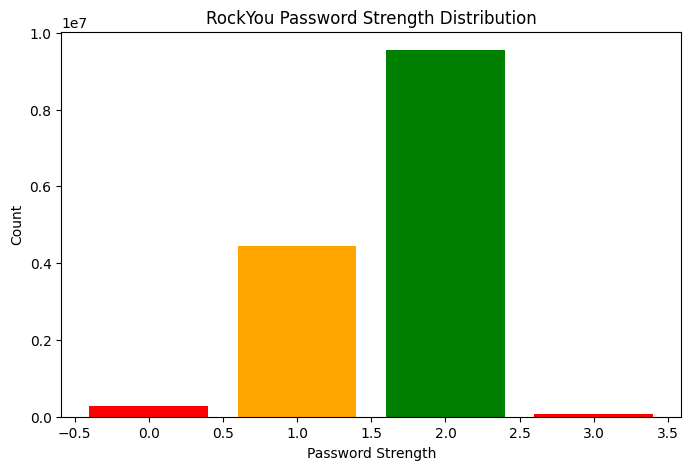

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(strength_counts.index, strength_counts.values, color=['red', 'orange', 'green'])

plt.xlabel('Password Strength')
plt.ylabel('Count')
plt.title('RockYou Password Strength Distribution')

plt.show()


In [ ]:
fig = px.bar(x=strength_counts.index, y=strength_counts.values, title="RockYou Password Strength Analysis",
             labels={"x": "Password Strength", "y": "Count"}, color=strength_counts.index)

fig.show()


In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color="black").generate(" ".join(df["password"]))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in RockYou Passwords")
plt.show()


<ipython-input-34-5de272a0860f>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strength_counts.index, y=strength_counts.values, palette="viridis")


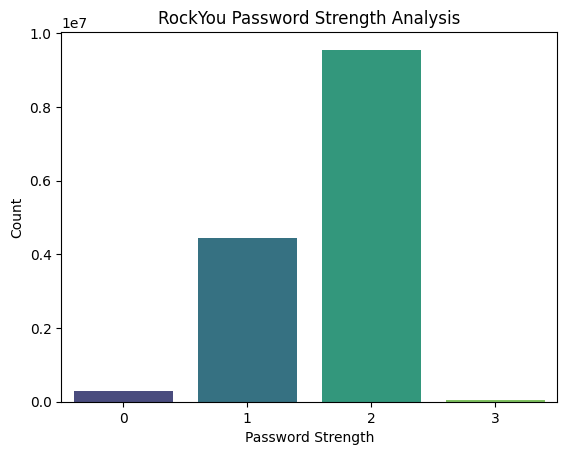

In [ ]:
sns.barplot(x=strength_counts.index, y=strength_counts.values, palette="viridis")

plt.xlabel('Password Strength')
plt.ylabel('Count')
plt.title('RockYou Password Strength Analysis')

plt.show()
